# NB02b — Logistic Regression Baseline vs LightGBM (Set A, LOYO CV)

**Question:** Does LightGBM provide measurable gains over a regularized linear model
using the same triage-only features and the same Leave-One-Year-Out validation scheme?

**Design:**
- Same Set A features (22 triage-only) as the principal LightGBM model
- Same LOYO folds (test one year at a time: 2016, 2017, 2018, 2019, 2022)
- Logistic Regression with L2 regularization, balanced class weights
- Imputation (median, train-fold only) + StandardScaler (train-fold only)
- C tuned by internal 5-fold StratifiedKFold on the training data of each LOYO fold
- Comparison at equal alert burden: Top 10% (ESI 3, 5) and Top 5% (ESI 4)


In [1]:
import os
import json
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# Fix CWD: VS Code Jupyter may start kernel in notebooks/ instead of project root
try:
    os.chdir(Path(__vsc_ipynb_file__).parent.parent)
except NameError:
    if Path(os.getcwd()).name == 'notebooks':
        os.chdir(Path(os.getcwd()).parent)

from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_PATH  = Path('data/processed/nhamcs_pooled_2016_2022.csv')
R02        = Path('reports/02_model_validation')
OUT        = Path('reports/02b_logistic_baseline')
OUT.mkdir(parents=True, exist_ok=True)

SEED = 42
N_BOOT = 1000
ESI_LIST = [3, 4, 5]
YEARS = [2016, 2017, 2018, 2019, 2022]

# Policy alert burdens (Top X%) — must match NB03
POLICY_TOP_PCT = {3: 10, 4: 5, 5: 10}

print("Imports OK.")
print(f"Output dir: {OUT}")


Imports OK.
Output dir: reports\02b_logistic_baseline


In [2]:
# ── Set A — identical to NB02 LightGBM principal model ───────────────────
SET_A = [
    'AGE', 'SEX', 'ARREMS',
    'temp_f', 'PULSE', 'RESPR', 'BPSYS', 'BPDIAS', 'POPCT', 'PAINSCALE',
    'RFV1', 'RFV2',
    'shock_index',
    'age_65plus', 'age_shock_index',
    'tachycardia_flag', 'tachypnea_flag', 'hypotension_flag', 'hypoxemia_flag',
    'fever_flag', 'bp_missing_flag', 'any_vital_missing_flag',
]
print(f"Set A: {len(SET_A)} features")

# Note on RFV codes: treated as numeric, same representation as LightGBM.
# LightGBM can split on specific code values via tree thresholds; LogReg
# treats them as a linear scale. This may partially disadvantage LogReg on
# chief complaint — noted in the interpretation section.

# ── Load training data ────────────────────────────────────────────────────
df_train = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded {len(df_train):,} rows, years: {sorted(df_train['year'].unique())}")

# ── Per-ESI missingness report ────────────────────────────────────────────
print()
print("Set A missingness (% missing, across all ESI 3-5):")
miss = df_train[SET_A].isnull().mean() * 100
for feat, pct in miss[miss > 0].sort_values(ascending=False).items():
    print(f"  {feat:<25} {pct:.1f}%")
if (miss == 0).all():
    print("  (all features complete)")


Set A: 22 features
Loaded 54,744 rows, years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022)]

Set A missingness (% missing, across all ESI 3-5):
  RFV2                      31.5%
  PAINSCALE                 23.3%
  shock_index               12.5%
  age_shock_index           12.5%
  BPDIAS                    10.4%
  BPSYS                     10.2%
  POPCT                     4.0%
  PULSE                     3.3%
  temp_f                    3.3%
  RESPR                     2.9%
  RFV1                      0.0%


In [3]:
# ── LOYO CV: Logistic Regression with internal C tuning ──────────────────
# For each LOYO fold:
#   1. Build train/test split by year
#   2. Fit median imputer on X_train, transform X_train and X_test
#   3. Fit StandardScaler on X_train_imputed, transform both
#   4. Tune C via LogisticRegressionCV (5-fold StratifiedKFold on train)
#   5. Predict proba on test fold
# Note: test fold is never seen in imputer, scaler, or C selection

Cs_GRID = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
INNER_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Store OOF predictions by ESI
oof_by_esi = {esi: [] for esi in ESI_LIST}
best_Cs    = {esi: [] for esi in ESI_LIST}

t0 = time.time()
for fold_num, test_year in enumerate(YEARS):
    train_years = [y for y in YEARS if y != test_year]
    print(f"Fold {fold_num+1}/5: test={test_year}  train={train_years}")

    for esi in ESI_LIST:
        mask_esi  = df_train['esi'] == esi
        df_esi    = df_train[mask_esi]

        mask_train = df_esi['year'].isin(train_years)
        mask_test  = df_esi['year'] == test_year

        X_tr = df_esi.loc[mask_train, SET_A].copy()
        y_tr = df_esi.loc[mask_train, 'outcome'].values
        X_te = df_esi.loc[mask_test,  SET_A].copy()
        y_te = df_esi.loc[mask_test,  'outcome'].values
        idx_te = df_esi.loc[mask_test].index

        if mask_test.sum() == 0 or y_tr.sum() == 0:
            continue

        # Impute with median (fit on train only)
        imputer = SimpleImputer(strategy='median')
        X_tr_imp = imputer.fit_transform(X_tr)
        X_te_imp = imputer.transform(X_te)

        # Scale (fit on train only)
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr_imp)
        X_te_sc = scaler.transform(X_te_imp)

        # Tune C via LogisticRegressionCV (internal 5-fold on train)
        lrcv = LogisticRegressionCV(
            Cs=Cs_GRID,
            cv=INNER_CV,
            penalty='l2',
            class_weight='balanced',
            solver='lbfgs',
            max_iter=2000,
            scoring='roc_auc',
            random_state=SEED,
            n_jobs=-1,
        )
        lrcv.fit(X_tr_sc, y_tr)
        best_C = float(lrcv.C_[0])
        best_Cs[esi].append(best_C)

        # Predict on test fold
        scores_te = lrcv.predict_proba(X_te_sc)[:, 1]

        for orig_idx, sc, yy in zip(idx_te, scores_te, y_te):
            oof_by_esi[esi].append({
                'year':      test_year,
                'orig_idx':  orig_idx,
                'logreg_score': float(sc),
                'outcome':   int(yy),
            })

elapsed = time.time() - t0
print(f"\nLOYO CV complete in {elapsed:.0f}s")
for esi in ESI_LIST:
    print(f"  ESI {esi}: {len(oof_by_esi[esi]):,} OOF predictions | best Cs: {best_Cs[esi]}")


Fold 1/5: test=2016  train=[2017, 2018, 2019, 2022]


Fold 2/5: test=2017  train=[2016, 2018, 2019, 2022]


Fold 3/5: test=2018  train=[2016, 2017, 2019, 2022]


Fold 4/5: test=2019  train=[2016, 2017, 2018, 2022]


Fold 5/5: test=2022  train=[2016, 2017, 2018, 2019]



LOYO CV complete in 10s
  ESI 3: 31,460 OOF predictions | best Cs: [0.1, 1.0, 0.1, 0.1, 1.0]
  ESI 4: 20,182 OOF predictions | best Cs: [0.001, 0.001, 0.01, 0.01, 0.001]
  ESI 5: 3,102 OOF predictions | best Cs: [0.01, 0.01, 0.01, 0.001, 0.01]


In [4]:
# Convert to DataFrames and add outcome components
oof_dfs = {}
for esi in ESI_LIST:
    df_oof = pd.DataFrame(oof_by_esi[esi]).sort_values('orig_idx').reset_index(drop=True)
    # Add outcome components from original data
    df_esi_all = df_train[df_train['esi'] == esi].copy()
    df_oof['ADMITHOS'] = df_esi_all.loc[df_oof['orig_idx'], 'ADMITHOS'].values
    df_oof['TRANOTH']  = df_esi_all.loc[df_oof['orig_idx'], 'TRANOTH'].values
    df_oof['DIEDED']   = df_esi_all.loc[df_oof['orig_idx'], 'DIEDED'].values
    df_oof['AGE']      = df_esi_all.loc[df_oof['orig_idx'], 'AGE'].values
    oof_dfs[esi] = df_oof

    df_oof.to_csv(OUT / f'02b_logreg_oof_esi{esi}.csv', index=False)
    pos = df_oof['outcome'].sum()
    print(f"ESI {esi}: {len(df_oof):,} rows | {pos} positives ({pos/len(df_oof):.3f}) | saved")


ESI 3: 31,460 rows | 4244 positives (0.135) | saved
ESI 4: 20,182 rows | 502 positives (0.025) | saved
ESI 5: 3,102 rows | 109 positives (0.035) | saved


In [5]:
# Load LightGBM OOF predictions from NB02 (Set A model)
lgbm_oof = {}
for esi in ESI_LIST:
    d = pd.read_csv(R02 / f'02_oof_predictions_esi{esi}.csv')
    lgbm_oof[esi] = d
    print(f"LGBM ESI {esi}: {len(d):,} rows | OOF cols: {list(d.columns)}")


LGBM ESI 3: 31,460 rows | OOF cols: ['year', 'outcome', 'ADMITHOS', 'TRANOTH', 'DIEDED', 'AGE', 'age_65plus', 'comorbidity_count', 'oof_score_A']
LGBM ESI 4: 20,182 rows | OOF cols: ['year', 'outcome', 'ADMITHOS', 'TRANOTH', 'DIEDED', 'AGE', 'age_65plus', 'comorbidity_count', 'oof_score_A']
LGBM ESI 5: 3,102 rows | OOF cols: ['year', 'outcome', 'ADMITHOS', 'TRANOTH', 'DIEDED', 'AGE', 'age_65plus', 'comorbidity_count', 'oof_score_A']


In [6]:
def bootstrap_auc(scores, y, n_boot=N_BOOT, seed=SEED):
    """Bootstrap 95% CI for ROC-AUC and PR-AUC."""
    rng = np.random.default_rng(seed)
    roc_aucs, pr_aucs = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        yb, sb = y[idx], scores[idx]
        if yb.sum() == 0 or (yb == 0).sum() == 0:
            continue
        roc_aucs.append(roc_auc_score(yb, sb))
        pr_aucs.append(average_precision_score(yb, sb))
    return {
        'roc_auc': float(np.mean(roc_aucs)),
        'roc_ci_lo': float(np.percentile(roc_aucs, 2.5)),
        'roc_ci_hi': float(np.percentile(roc_aucs, 97.5)),
        'pr_auc': float(np.mean(pr_aucs)),
        'pr_ci_lo': float(np.percentile(pr_aucs, 2.5)),
        'pr_ci_hi': float(np.percentile(pr_aucs, 97.5)),
    }

def policy_metrics_at_pct(scores, y, top_pct, n_boot=N_BOOT, seed=SEED):
    """Compute PPV, enrichment, recall at a given top-X% percentile cutoff."""
    cutoff = float(np.percentile(scores, 100 - top_pct))
    alerted = scores >= cutoff
    base_rate = float(y.mean())

    rng = np.random.default_rng(seed)
    ppvs, enrs, recalls = [], [], []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        yb, ab = y[idx], alerted[idx]
        if ab.sum() == 0 or yb.sum() == 0:
            continue
        ppv = float(yb[ab].mean())
        ppvs.append(ppv)
        enrs.append(ppv / base_rate)
        recalls.append(float(yb[ab].sum() / yb.sum()))

    actual_burden = float(alerted.mean() * 100)
    actual_ppv    = float(y[alerted].mean()) if alerted.sum() > 0 else 0
    actual_enr    = actual_ppv / base_rate if base_rate > 0 else 0
    actual_recall = float(y[alerted].sum() / y.sum()) if y.sum() > 0 else 0

    return {
        'cutoff':      round(cutoff, 4),
        'burden_pct':  round(actual_burden, 2),
        'base_rate':   round(base_rate, 4),
        'ppv':         round(actual_ppv, 4),
        'enrichment':  round(actual_enr, 4),
        'recall':      round(actual_recall, 4),
        'enrichment_ci': (round(float(np.percentile(enrs, 2.5)), 3),
                          round(float(np.percentile(enrs, 97.5)), 3)),
        'ppv_ci':        (round(float(np.percentile(ppvs, 2.5)), 3),
                          round(float(np.percentile(ppvs, 97.5)), 3)),
    }

print("Metric functions defined.")


Metric functions defined.


In [7]:
print("Computing metrics (bootstrap n=1000)... this may take ~60s")
t0 = time.time()

results = []
for esi in ESI_LIST:
    top_pct = POLICY_TOP_PCT[esi]

    # ── LogReg ──────────────────────────────────────────────────────────
    df_lr  = oof_dfs[esi]
    sc_lr  = df_lr['logreg_score'].values
    y_lr   = df_lr['outcome'].values

    auc_lr = bootstrap_auc(sc_lr, y_lr)
    pol_lr = policy_metrics_at_pct(sc_lr, y_lr, top_pct)

    results.append({
        'esi': esi, 'model': 'LogReg L2',
        'n': len(y_lr), 'n_pos': int(y_lr.sum()),
        'roc_auc': auc_lr['roc_auc'],
        'roc_ci_lo': auc_lr['roc_ci_lo'], 'roc_ci_hi': auc_lr['roc_ci_hi'],
        'pr_auc': auc_lr['pr_auc'],
        'pr_ci_lo': auc_lr['pr_ci_lo'], 'pr_ci_hi': auc_lr['pr_ci_hi'],
        'policy_pct': top_pct,
        'ppv': pol_lr['ppv'], 'ppv_ci': pol_lr['ppv_ci'],
        'enrichment': pol_lr['enrichment'], 'enrichment_ci': pol_lr['enrichment_ci'],
        'recall': pol_lr['recall'],
        'burden_pct': pol_lr['burden_pct'],
    })

    # ── LightGBM ────────────────────────────────────────────────────────
    df_lg  = lgbm_oof[esi]
    sc_lg  = df_lg['oof_score_A'].values
    y_lg   = df_lg['outcome'].values

    auc_lg = bootstrap_auc(sc_lg, y_lg)
    pol_lg = policy_metrics_at_pct(sc_lg, y_lg, top_pct)

    results.append({
        'esi': esi, 'model': 'LightGBM',
        'n': len(y_lg), 'n_pos': int(y_lg.sum()),
        'roc_auc': auc_lg['roc_auc'],
        'roc_ci_lo': auc_lg['roc_ci_lo'], 'roc_ci_hi': auc_lg['roc_ci_hi'],
        'pr_auc': auc_lg['pr_auc'],
        'pr_ci_lo': auc_lg['pr_ci_lo'], 'pr_ci_hi': auc_lg['pr_ci_hi'],
        'policy_pct': top_pct,
        'ppv': pol_lg['ppv'], 'ppv_ci': pol_lg['ppv_ci'],
        'enrichment': pol_lg['enrichment'], 'enrichment_ci': pol_lg['enrichment_ci'],
        'recall': pol_lg['recall'],
        'burden_pct': pol_lg['burden_pct'],
    })

df_results = pd.DataFrame(results).sort_values(['esi', 'model'])
print(f"Done in {time.time()-t0:.0f}s")


Computing metrics (bootstrap n=1000)... this may take ~60s


Done in 32s


In [8]:
print("=" * 100)
print("LOGISTIC REGRESSION vs LIGHTGBM — Set A (Triage-Only), LOYO CV")
print("=" * 100)
print(f"{'ESI':>4} {'Model':<14} {'N':>7} {'ROC AUC':>9} {'[95% CI]':>18} "
      f"{'PR AUC':>8} {'Burden':>7} {'PPV':>7} {'Enrichment':>12} {'[95% CI]':>14} {'Recall':>8}")
print("-" * 100)

for _, row in df_results.iterrows():
    ci_roc = f"[{row['roc_ci_lo']:.4f}–{row['roc_ci_hi']:.4f}]"
    ci_enr = f"[{row['enrichment_ci'][0]:.2f}–{row['enrichment_ci'][1]:.2f}]"
    print(f"  {row['esi']}  {row['model']:<14} {row['n']:>7,}  "
          f"{row['roc_auc']:>9.4f}  {ci_roc:>18}  "
          f"{row['pr_auc']:>8.4f}  {row['burden_pct']:>6.1f}%  "
          f"{row['ppv']:>7.4f}  {row['enrichment']:>12.4f}  {ci_enr:>14}  "
          f"{row['recall']:>8.4f}")
    if row['model'] == 'LightGBM' and row['esi'] < 5:
        print()

print("=" * 100)
print(f"Policy burdens: ESI3 Top {POLICY_TOP_PCT[3]}%, ESI4 Top {POLICY_TOP_PCT[4]}%, ESI5 Top {POLICY_TOP_PCT[5]}%")
print("Metrics computed on OOF predictions (each patient scored on held-out year).")
print("CI: 1000 bootstrap samples of the full OOF pool.")


LOGISTIC REGRESSION vs LIGHTGBM — Set A (Triage-Only), LOYO CV
 ESI Model                N   ROC AUC           [95% CI]   PR AUC  Burden     PPV   Enrichment       [95% CI]   Recall
----------------------------------------------------------------------------------------------------
  3  LightGBM        31,460     0.7463     [0.7385–0.7541]    0.3636    10.0%   0.4196        3.1103     [2.99–3.23]    0.3110

  3  LogReg L2       31,460     0.7255     [0.7169–0.7339]    0.3206    10.0%   0.3824        2.8346     [2.70–2.97]    0.2835
  4  LightGBM        20,182     0.7455     [0.7222–0.7668]    0.1136     5.0%   0.1436        5.7717     [4.91–6.63]    0.2888

  4  LogReg L2       20,182     0.7426     [0.7193–0.7650]    0.0906     5.0%   0.1257        5.0553     [4.20–5.87]    0.2530
  5  LightGBM         3,102     0.7412     [0.6925–0.7911]    0.1607    10.0%   0.1511        4.3008     [3.15–5.46]    0.4312
  5  LogReg L2        3,102     0.8099     [0.7719–0.8495]    0.1781    10.0%   

In [9]:
print("Delta AUC: LightGBM minus LogReg (positive = LGBM advantage)")
print("-"*55)
for esi in ESI_LIST:
    lr_row  = df_results[(df_results['esi']==esi) & (df_results['model']=='LogReg L2')].iloc[0]
    lgbm_row= df_results[(df_results['esi']==esi) & (df_results['model']=='LightGBM')].iloc[0]
    delta_roc = lgbm_row['roc_auc'] - lr_row['roc_auc']
    delta_pr  = lgbm_row['pr_auc']  - lr_row['pr_auc']
    delta_enr = lgbm_row['enrichment'] - lr_row['enrichment']
    overlap   = not (lgbm_row['enrichment_ci'][0] > lr_row['enrichment_ci'][1] or
                     lr_row['enrichment_ci'][0]  > lgbm_row['enrichment_ci'][1])
    verdict = 'CI OVERLAP — not clearly distinct' if overlap else 'NON-OVERLAPPING CI'
    print(f"  ESI {esi}: dROC={delta_roc:+.4f}  dPR={delta_pr:+.4f}  dEnrich={delta_enr:+.4f}x  [{verdict}]")


Delta AUC: LightGBM minus LogReg (positive = LGBM advantage)
-------------------------------------------------------
  ESI 3: dROC=+0.0208  dPR=+0.0430  dEnrich=+0.2757x  [NON-OVERLAPPING CI]
  ESI 4: dROC=+0.0028  dPR=+0.0230  dEnrich=+0.7164x  [CI OVERLAP — not clearly distinct]
  ESI 5: dROC=-0.0687  dPR=-0.0174  dEnrich=+0.1830x  [CI OVERLAP — not clearly distinct]


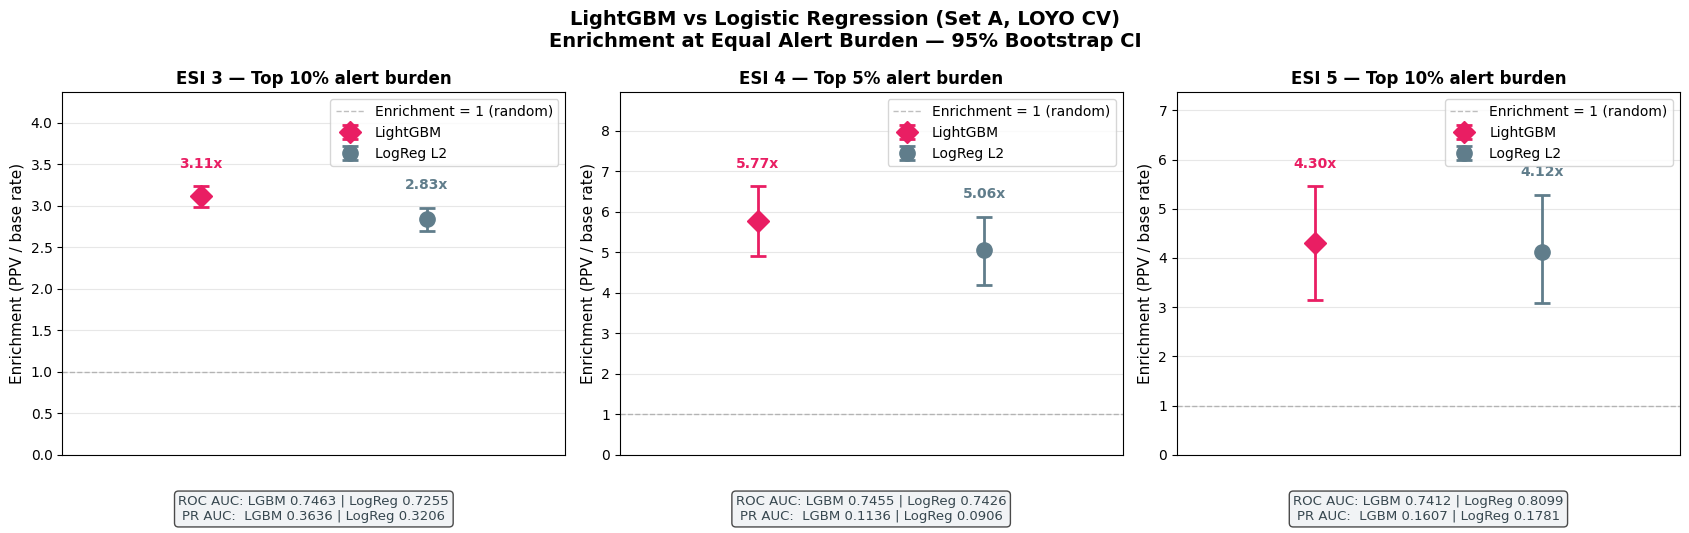

Figure saved: reports\02b_logistic_baseline\02b_logreg_vs_lgbm.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle('LightGBM vs Logistic Regression (Set A, LOYO CV)\n'
             'Enrichment at Equal Alert Burden — 95% Bootstrap CI',
             fontsize=14, fontweight='bold')

ESI_COLORS   = {3: '#2196F3', 4: '#FF9800', 5: '#4CAF50'}
MODEL_COLORS = {'LightGBM': '#E91E63', 'LogReg L2': '#607D8B'}
X_OFFSET     = {'LightGBM': -0.18, 'LogReg L2': 0.18}
MARKERS      = {'LightGBM': 'D', 'LogReg L2': 'o'}

for ax, esi in zip(axes, ESI_LIST):
    ax.set_title(f'ESI {esi} — Top {POLICY_TOP_PCT[esi]}% alert burden',
                 fontsize=12, fontweight='bold')

    rows = {model: df_results[(df_results['esi']==esi) & (df_results['model']==model)].iloc[0]
            for model in ['LightGBM', 'LogReg L2']}
    panel_max_hi = max(rows[m]['enrichment_ci'][1] for m in rows)
    # Offset and ylim are scaled to this panel's own data range (not a flat
    # constant) so the bold label always clears the error-bar cap with visible
    # whitespace, regardless of whether enrichment is ~1x or ~9x in this ESI.
    label_offset = panel_max_hi * 0.07

    for model in ['LightGBM', 'LogReg L2']:
        row = rows[model]
        x = 1 + X_OFFSET[model]
        enr  = row['enrichment']
        lo, hi = row['enrichment_ci']
        ax.errorbar(x, enr, yerr=[[enr-lo],[hi-enr]],
                    fmt=MARKERS[model], color=MODEL_COLORS[model],
                    markersize=11, capsize=6, lw=2, capthick=2,
                    label=model)
        ax.text(x, hi + label_offset, f'{enr:.2f}x', ha='center', fontsize=10,
                fontweight='bold', color=MODEL_COLORS[model])

    ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.5, label='Enrichment = 1 (random)')
    ax.set_ylabel('Enrichment (PPV / base rate)', fontsize=11)
    ax.set_xticks([])
    ax.set_xlim([0.6, 1.4])
    ax.set_ylim([0, panel_max_hi * 1.35])
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=10, loc='upper right')

    # Add AUC annotation at the bottom
    lr_row   = rows['LogReg L2']
    lgbm_row = rows['LightGBM']
    ax.text(0.5, -0.18,
            f"ROC AUC: LGBM {lgbm_row['roc_auc']:.4f} | LogReg {lr_row['roc_auc']:.4f}\n"
            f"PR AUC:  LGBM {lgbm_row['pr_auc']:.4f} | LogReg {lr_row['pr_auc']:.4f}",
            transform=ax.transAxes, ha='center', fontsize=9.5, color='#37474F',
            bbox=dict(boxstyle='round,pad=0.3', fc='#ECEFF1', alpha=0.7))

plt.tight_layout()
out_fig = OUT / '02b_logreg_vs_lgbm.png'
plt.savefig(str(out_fig), dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {out_fig}")


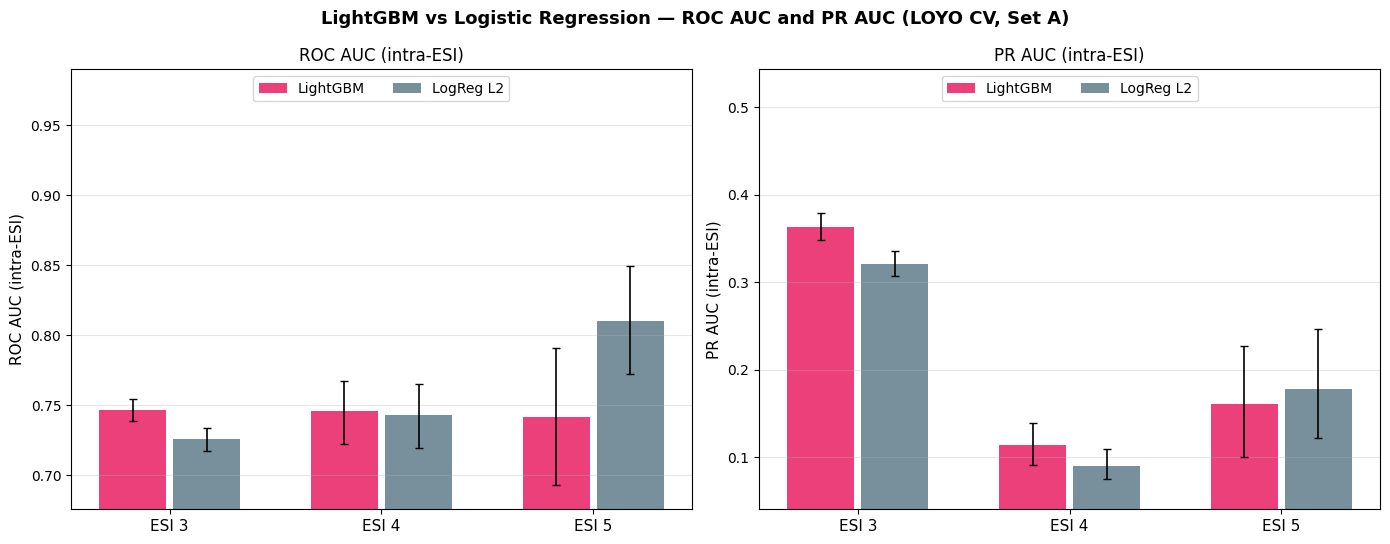

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('LightGBM vs Logistic Regression — ROC AUC and PR AUC (LOYO CV, Set A)',
             fontsize=13, fontweight='bold')

for ax, metric, label in [
    (axes[0], 'roc_auc', 'ROC AUC (intra-ESI)'),
    (axes[1], 'pr_auc',  'PR AUC (intra-ESI)'),
]:
    x     = np.arange(3)
    width = 0.35
    for xi, esi in enumerate(ESI_LIST):
        for j, (model, color) in enumerate([('LightGBM','#E91E63'), ('LogReg L2','#607D8B')]):
            row = df_results[(df_results['esi']==esi) & (df_results['model']==model)].iloc[0]
            xpos = xi + (j - 0.5) * width
            ax.bar(xpos, row[metric], width*0.9, color=color, alpha=0.85,
                   label=model if xi == 0 else '')
            err_lo = row[metric] - row[f'{metric.split("_")[0]}_ci_lo']
            err_hi = row[f'{metric.split("_")[0]}_ci_hi'] - row[metric]
            ax.errorbar(xpos, row[metric], yerr=[[err_lo],[err_hi]],
                        fmt='none', color='black', capsize=3, lw=1.2)

    ax.set_xticks(np.arange(3))
    ax.set_xticklabels([f'ESI {e}' for e in ESI_LIST], fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(axis='y', alpha=0.3)
    ymin = df_results[metric].min() - 0.05
    # Extra headroom (+0.18 instead of +0.05) so the legend has dedicated empty
    # space at the top instead of competing with bars for the same +0.05 strip.
    ymax = df_results[metric].max() + 0.18
    ax.set_ylim([max(0, ymin), ymax])
    ax.legend(fontsize=10, loc='upper center', ncol=2)

plt.tight_layout()
plt.savefig(str(OUT / '02b_logreg_vs_lgbm_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# ── Auto-generate interpretation based on results ─────────────────────────
print("=" * 65)
print("INTERPRETATION")
print("=" * 65)

for esi in ESI_LIST:
    lr   = df_results[(df_results['esi']==esi) & (df_results['model']=='LogReg L2')].iloc[0]
    lgbm = df_results[(df_results['esi']==esi) & (df_results['model']=='LightGBM')].iloc[0]

    delta_roc = lgbm['roc_auc'] - lr['roc_auc']
    delta_enr = lgbm['enrichment'] - lr['enrichment']
    ci_overlap = not (lgbm['enrichment_ci'][0] > lr['enrichment_ci'][1] or
                      lr['enrichment_ci'][0]  > lgbm['enrichment_ci'][1])

    if abs(delta_roc) < 0.01 and ci_overlap:
        verdict = "COMPARABLE — no clear advantage to gradient boosting"
    elif delta_roc > 0.015 and not ci_overlap:
        verdict = "LGBM CLEARLY BETTER — non-linear interactions provide measurable gains"
    elif delta_roc > 0.005:
        verdict = "LGBM MODESTLY BETTER — small gain, CI likely overlapping"
    elif delta_roc < -0.005:
        verdict = "LOGREG COMPETITIVE — linear model not disadvantaged"
    else:
        verdict = "EFFECTIVELY TIED"

    print(f"\nESI {esi}:")
    print(f"  LightGBM:  ROC AUC={lgbm['roc_auc']:.4f} | Enrichment={lgbm['enrichment']:.3f}x")
    print(f"  LogReg L2: ROC AUC={lr['roc_auc']:.4f} | Enrichment={lr['enrichment']:.3f}x")
    print(f"  Delta ROC: {delta_roc:+.4f}  |  Delta Enrichment: {delta_enr:+.3f}x")
    print(f"  CI overlap on enrichment: {ci_overlap}")
    print(f"  Verdict: {verdict}")

print()
print("Note on RFV codes: treated as numeric for both models (same representation).")
print("LightGBM can split on specific code values via tree thresholds;")
print("LogReg treats them as a linear scale. This may partially disadvantage")
print("LogReg on chief complaint — any residual gap may reflect this, not")
print("non-linearity in the clinical signal itself.")
print()
print("=" * 65)


INTERPRETATION

ESI 3:
  LightGBM:  ROC AUC=0.7463 | Enrichment=3.110x
  LogReg L2: ROC AUC=0.7255 | Enrichment=2.835x
  Delta ROC: +0.0208  |  Delta Enrichment: +0.276x
  CI overlap on enrichment: False
  Verdict: LGBM CLEARLY BETTER — non-linear interactions provide measurable gains

ESI 4:
  LightGBM:  ROC AUC=0.7455 | Enrichment=5.772x
  LogReg L2: ROC AUC=0.7426 | Enrichment=5.055x
  Delta ROC: +0.0028  |  Delta Enrichment: +0.716x
  CI overlap on enrichment: True
  Verdict: COMPARABLE — no clear advantage to gradient boosting

ESI 5:
  LightGBM:  ROC AUC=0.7412 | Enrichment=4.301x
  LogReg L2: ROC AUC=0.8099 | Enrichment=4.118x
  Delta ROC: -0.0687  |  Delta Enrichment: +0.183x
  CI overlap on enrichment: True
  Verdict: LOGREG COMPETITIVE — linear model not disadvantaged

Note on RFV codes: treated as numeric for both models (same representation).
LightGBM can split on specific code values via tree thresholds;
LogReg treats them as a linear scale. This may partially disadvantage

In [13]:
# Save comparison table
df_results.to_csv(OUT / '02b_logreg_vs_lgbm.csv', index=False)

# Save summary JSON
summary = []
for esi in ESI_LIST:
    for model in ['LightGBM', 'LogReg L2']:
        row = df_results[(df_results['esi']==esi) & (df_results['model']==model)].iloc[0]
        entry = row.to_dict()
        entry['enrichment_ci'] = list(entry['enrichment_ci'])
        entry['ppv_ci']        = list(entry['ppv_ci'])
        summary.append(entry)

with open(OUT / '02b_logreg_vs_lgbm.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Best Cs by ESI
best_Cs_by_esi = {str(esi): {str(y): c for y, c in zip(YEARS, best_Cs[esi])}
                  for esi in ESI_LIST}
with open(OUT / '02b_best_Cs.json', 'w') as f:
    json.dump(best_Cs_by_esi, f, indent=2)

print("Saved to reports/02b_logistic_baseline/:")
print("  02b_logreg_vs_lgbm.csv")
print("  02b_logreg_vs_lgbm.json")
print("  02b_logreg_vs_lgbm.png")
print("  02b_logreg_vs_lgbm_auc.png")
print("  02b_best_Cs.json")
print(f"  02b_logreg_oof_esi{{3,4,5}}.csv")


Saved to reports/02b_logistic_baseline/:
  02b_logreg_vs_lgbm.csv
  02b_logreg_vs_lgbm.json
  02b_logreg_vs_lgbm.png
  02b_logreg_vs_lgbm_auc.png
  02b_best_Cs.json
  02b_logreg_oof_esi{3,4,5}.csv


In [14]:
print("Selected C values by ESI and fold:")
print(f"  {'ESI':<5} {'2016':>8} {'2017':>8} {'2018':>8} {'2019':>8} {'2022':>8}  Mean")
for esi in ESI_LIST:
    cs = best_Cs[esi]
    if cs:
        print(f"  ESI {esi}  " + "  ".join(f"{c:>8.3f}" for c in cs) +
              f"  {np.mean(cs):.3f}")
print()
print("C close to 1.0 suggests the model is not strongly regularized on this dataset.")
print("C << 1.0 would indicate high regularization needed (noisy/correlated features).")


Selected C values by ESI and fold:
  ESI       2016     2017     2018     2019     2022  Mean
  ESI 3     0.100     1.000     0.100     0.100     1.000  0.460
  ESI 4     0.001     0.001     0.010     0.010     0.001  0.005
  ESI 5     0.010     0.010     0.010     0.001     0.010  0.008

C close to 1.0 suggests the model is not strongly regularized on this dataset.
C << 1.0 would indicate high regularization needed (noisy/correlated features).
